데이터 출처: https://www.kaggle.com/datasets/tatheerabbas/psychological-manipulation-conversations-dataset

위의 LLM을 통하여 인위적으로 생성된 데이터로 텍스트 속에서 심리조작기법을 분석하며 그 조작기법에 따른 사람의 감정 영향을 나타낸 데이터입니다.

In [ ]:
import pandas as pd



file_path = r"/content/manipulational_conversation.jsonl" # 예시 경로

# jsonl 파일 불러오기
df = pd.read_json(file_path, lines=True)

# 데이터 확인
print("데이터의 크기:", df.shape)
display(df.head())


데이터의 크기: (10000, 21)


,conversation_id,manipulation_type,is_manipulation,context_type,conversation_length,manipulation_intensity,messages,target_confusion,guilt_level,fear_level,...,self_doubt,target_extraversion,target_emotional_resilience,target_assertiveness,target_attachment_style,avg_response_delay_seconds,escalation_pattern,word_count_total,question_count,denial_count
0,conv_00000,guilt_tripping,True,friend,3,0.705,"[{'speaker': 'A', 'text': 'Remember when I hel...",0.136,0.797,0.224,...,0.306,0.375,0.101,0.222,disorganized,162,sudden,28,1,0
1,conv_00001,charm_flattery,True,friend,6,0.530,"[{'speaker': 'A', 'text': 'I don't tell just a...",0.219,0.306,0.041,...,0.459,0.366,0.380,0.342,secure,93,gradual,51,2,5
2,conv_00002,direct_coercion,True,family,7,0.651,"[{'speaker': 'A', 'text': 'Just do it', 'senti...",0.253,0.166,0.760,...,0.335,0.259,0.064,0.201,anxious,58,gradual,37,1,6
3,conv_00003,gaslighting,True,friend,6,0.673,"[{'speaker': 'A', 'text': 'You're being way to...",0.702,0.123,0.194,...,0.799,0.987,0.168,0.422,disorganized,342,cyclical,41,0,5
4,conv_00004,guilt_tripping,True,friend,4,0.331,"[{'speaker': 'A', 'text': 'Go ahead. Have fun....",0.173,0.666,0.126,...,0.355,0.120,0.331,0.787,secure,299,cyclical,25,1,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   conversation_id              10000 non-null  object 
 1   manipulation_type            10000 non-null  object 
 2   is_manipulation              10000 non-null  bool   
 3   context_type                 10000 non-null  object 
 4   conversation_length          10000 non-null  int64  
 5   manipulation_intensity       10000 non-null  float64
 6   messages                     10000 non-null  object 
 7   target_confusion             10000 non-null  float64
 8   guilt_level                  10000 non-null  float64
 9   fear_level                   10000 non-null  float64
 10  anxiety_level                10000 non-null  float64
 11  self_doubt                   10000 non-null  float64
 12  target_extraversion          10000 non-null  float64
 13  target_emotional_

**[기초통계 확인]**

In [ ]:
display(df.describe())

,conversation_length,manipulation_intensity,target_confusion,guilt_level,fear_level,anxiety_level,self_doubt,target_extraversion,target_emotional_resilience,target_assertiveness,avg_response_delay_seconds,word_count_total,question_count,denial_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.502300,0.517148,0.344116,0.321732,0.245987,0.438082,0.392572,0.502461,0.303966,0.328283,195.177200,37.166400,1.04590,3.383000
std,1.709177,0.294557,0.235967,0.231932,0.262769,0.253414,0.234436,0.286287,0.192512,0.209750,154.763492,11.492707,0.96555,2.290161
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001000,18.000000,4.000000,0.00000,0.000000
25%,4.000000,0.335000,0.146000,0.156000,0.063000,0.217000,0.205000,0.256000,0.160000,0.170000,73.000000,28.000000,0.00000,2.000000
50%,6.000000,0.561000,0.308000,0.280000,0.162500,0.439000,0.395500,0.507000,0.268000,0.288000,122.000000,37.000000,1.00000,3.000000
75%,7.000000,0.747000,0.526000,0.405000,0.300000,0.659000,0.528000,0.748000,0.408000,0.442000,288.000000,46.000000,2.00000,5.000000
max,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,599.000000,67.000000,5.00000,12.000000


In [ ]:
print(df['manipulation_type'].unique())
print(df['target_attachment_style'].unique())

['guilt_tripping' 'charm_flattery' 'direct_coercion' 'gaslighting'
 'love_bombing' 'neutral' 'passive_aggressive']
['disorganized' 'secure' 'anxious' 'avoidant']


In [ ]:
print(df['manipulation_type'].value_counts())
print(df['target_attachment_style'].value_counts())

manipulation_type
neutral               1600
charm_flattery        1400
guilt_tripping        1400
direct_coercion       1400
gaslighting           1400
love_bombing          1400
passive_aggressive    1400
Name: count, dtype: int64
target_attachment_style
anxious         4209
avoidant        2412
secure          1988
disorganized    1391
Name: count, dtype: int64


 다양한 심리 조작 기법(manipulation_type)과 내면적 성향인 애착 유형(target_attachment_style)이 타겟의 심리적 지표(불안, 혼란, 자기 의심 등)에 미치는 영향을 분석하는 것에 목적을 두었습니다. 특히 각 지표 간의 상관관계를 통해 조작기법이 어떻게 심리적 연쇄 반응을 일으키는지 파악하고자 합니다.

조작강도에 따른 심리지표

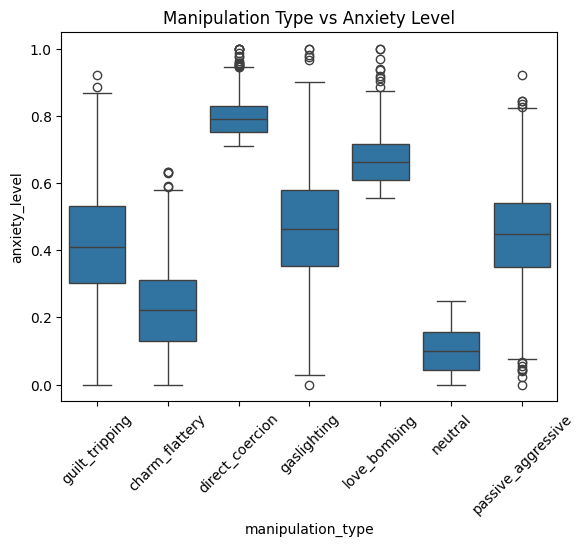

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(data=df, x='manipulation_type', y='anxiety_level')#x축을 'manipulation_type'으로 y축을 'anxiety level' 로 하는 상자그림
plt.title('Manipulation Type vs Anxiety Level')
plt.xticks(rotation=45) #x축라벨이 겹치지 않도록 회전
plt.show()

수치형 변수들 선택하여 상관관계 분석

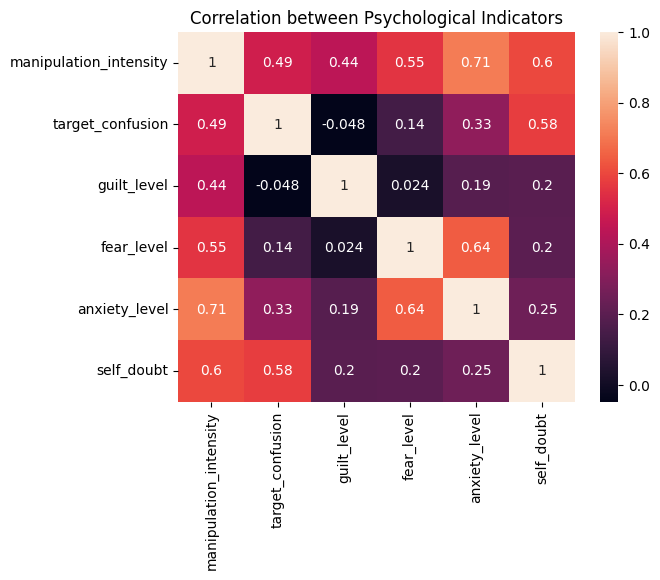

In [ ]:
cols = ['manipulation_intensity', 'target_confusion', 'guilt_level', 'fear_level', 'anxiety_level', 'self_doubt'] #수치형 변수들만 선택
sns.heatmap(df[cols].corr(), annot=True) #cols에 정의된 컬럼만 선택하여 상관행렬 계산 후 히트맵 생성
plt.title('Correlation between Psychological Indicators')
plt.show()

애착유형별 불안 수치

/tmp/ipykernel_294/1411481318.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='target_attachment_style', y='anxiety_level', palette='muted')


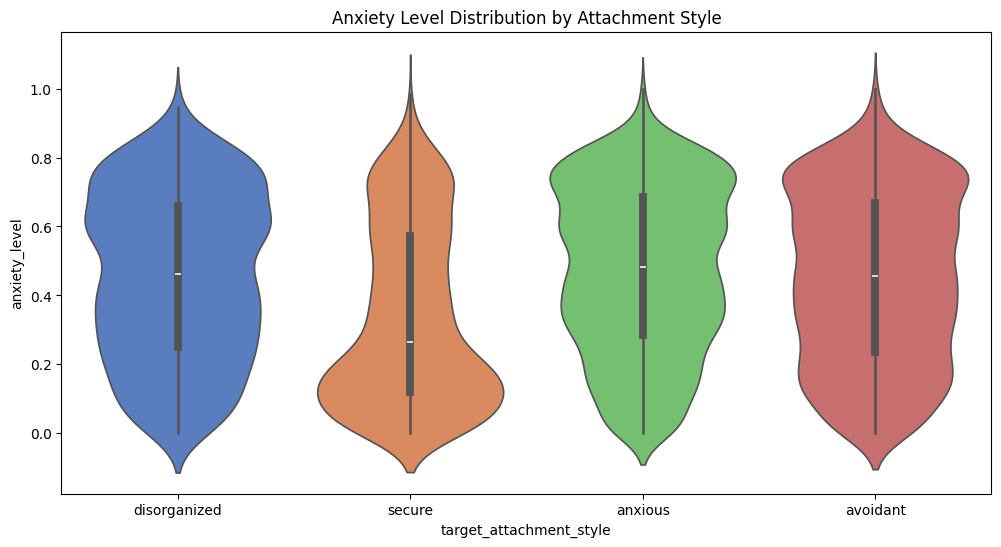

In [ ]:
# 애착 유형별로 불안 수치의 분포 모양을 비교
sns.violinplot(data=df, x='target_attachment_style', y='anxiety_level', palette='muted')

plt.title('Anxiety Level Distribution by Attachment Style')
plt.show()

manipulation_intensity는 anxiety_level(0.71) 및 self_doubt(0.60)와 강한 상관계를 보임.

 불안 수치가(anxiety_level) 높아질 때 공포 수치(fear_level, 0.64)도 함께 급증하는 양상.

 세번째 시각화인 바이올린 플롯을 보면 'Secure(안정형)' 유형은 다른 유형에 비해 불안 수치가 낮은 지점에 밀집되어 있음. 반대로'Anxious(불안형)'와 'Avoidant(회피형)'는 불안 수치가 높은 구간에 넓게 퍼져 있음.